# Exploring `build_cutouts` outputs

This jupyter notebook analyse the `build_cutout.py` **outputs**. Cutouts are returning wind, solar and run-off river relevant timeseries that are created with the Atlite tool (wind speeds, solar iradiation, etc.). We recommend going through [Atlite's notebooks](https://github.com/PyPSA/atlite/tree/master/examples) to learn more about it's fantastic capabilities.

The `pypsa-earth/Snakefile` explicitly list in the **rule** what goes into the function `build_cutouts.py` and what goes out (`networks/{cutout}.nc`). So to create the i.e. wind speed timeseries, we only need to provide shapes of the area of interest as input and automatically can create outputs.

```
if config['enable'].get('build_cutout', False):
    rule build_cutout:
        input:
            regions_onshore="resources/regions_onshore.geojson",
            regions_offshore="resources/regions_offshore.geojson"
        output: "cutouts/{cutout}.nc"
        log: "logs/build_cutout/{cutout}.log"
        benchmark: "benchmarks/build_cutout_{cutout}"
        threads: ATLITE_NPROCESSES
        resources: mem=ATLITE_NPROCESSES * 1000
        script: "scripts/build_cutout.py"
```

Before analysing the outputs of add_electricity.py check that:
- `pypsa-earth` environment (/kernel) in jupyter notebook  is active and updated
- root folder where pypsa-earth is installed is named "pypsa-earth"
- or rename the below `sets_path_to_root("<folder_name>")` accordingly

In [4]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

A jupyter notebook requires the user to import all they need. So we need to import all the required dependencies from the `pypsa-earth` environment:

In [5]:
import atlite
import cartopy.crs as ccrs
import xarray as xr
import geopandas as gpd
import geoviews as gv
import holoviews as hv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import pypsa
import shutil
from rasterio.plot import show
from atlite.gis import shape_availability, ExclusionContainer

plt.rcParams["figure.figsize"] = [7, 7]
%matplotlib inline

## Create a cutout (takes quite a while)
If you don't have already an cutout for instance `pypsa-earth/cutouts/africa-2013-era5.nc` in your folder you need to create one (or download one through our google cloud). Note: That we only provide the cutout for whole Africa at the moment. If another regions is of interest you need to do the following:

- Go through the Atlite example: https://github.com/PyPSA/atlite/blob/master/examples/create_cutout.ipynb (as described there, we need to setup some stuff to download cutouts)
- Copy and rename the `config_default.yaml` to `config.yaml`
- Change the `config.yaml` if needed:

```
atlite:
  nprocesses: 4
  cutouts:
    africa-2013-era5:         # This can be renamed for instance mena-2013-era5
      module: era5            # dataset
      dx: 0.3                 # raster/ cutout resolution 
      dy: 0.3                 # raster/ cutout resolution
      time: ["2013", "2013"]  # weather year of interest. 2013 is default. 
```
- provide the input shapes of the **Snakefile rule** for the region of interest. Make sure that for instance `regions_onshore.geojson` contains the data of Middle-East if you want to create a cutout of this area **and** this file need to be located in `pypsa-earth/resources` according to the Snakefile rule:
```    
    input:
            regions_onshore="resources/regions_onshore.geojson",
            regions_offshore="resources/regions_offshore.geojson"
```
- execute the following command when located at `~/pypsa-earth`:
```
    snakemake -j 1 cutouts/africa-2013-era5.nc
    or
    snakemake -j 1 cutouts/mena-2013-era5.nc
```
, depending on which name you defined in the `config.yaml` **and** in the `Snakefile`

## Let's open the cutouts = weather/environment cells
Cutouts in Atlite are rasterized weather and environment cells. They are produced in the `build_cutouts.py` and lead to the output `africa-2013-era5.nc` which is stored in the `pypsa-earth/cutouts` folder. We read first the path and open then the .nc file with xarray. As you can see from the ploted content below there is quite a lot data available. All data variabes are grided (x,y) and most of them even over time. Let's have a look.

In [6]:
# weather_cell_path = os.path.realpath("pypsa-earth/cutouts") + "/africa-2013-era5-tutorial.nc"  # NOTE: this works if you are using the tutorial configuration
# weather_cell_path = os.path.realpath("pypsa-earth/cutouts") + "/africa-2013-era5.nc"  # if you are using the default configuration, please use this
weather_cell_path = os.path.realpath("pypsa-earth/cutouts") + "/cutout-2013-era5.nc"
weather_cell = xr.open_dataset(weather_cell_path)

In [7]:
weather_cell

<xarray.Dataset> Size: 29GB
Dimensions:           (x: 291, y: 257, time: 8760)
Coordinates:
  * x                 (x) float64 2kB -19.5 -19.2 -18.9 -18.6 ... 66.9 67.2 67.5
  * y                 (y) float64 2kB -37.5 -37.2 -36.9 -36.6 ... 38.7 39.0 39.3
  * time              (time) datetime64[ns] 70kB 2013-01-01 ... 2013-12-31T23...
    lon               (x) float64 2kB ...
    lat               (y) float64 2kB ...
Data variables:
    height            (y, x) float32 299kB ...
    wnd100m           (time, y, x) float32 3GB ...
    roughness         (time, y, x) float32 3GB ...
    influx_toa        (time, y, x) float32 3GB ...
    influx_direct     (time, y, x) float32 3GB ...
    influx_diffuse    (time, y, x) float32 3GB ...
    albedo            (time, y, x) float32 3GB ...
    temperature       (time, y, x) float64 5GB ...
    soil temperature  (time, y, x) float64 5GB ...
    runoff            (time, y, x) float32 3GB ...
Attributes:
    module:             era5
    prepared_features:  ['runoff', 'influx', 'height', 'temperature', 'wind']
    chunksize_time:     100
    dx:                 0.3
    dy:                 0.3
    Conventions:        CF-1.6
    history:            2021-08-16 23:35:34 GMT by grib_to_netcdf-2.20.0: /op...

## Assessing the height profile

Assessing the smooth map below, you might recognise that the maximum value is 3438m. But actually the highest mountain in Africa is the Mount Kilimanjaro with an elevation of 5,895m. So what's going wrong? Nothing. As you might remember from the Atlite examples, each cutout cell is about 20 x 20km depending where you are in the world. All values in the cells are averaged therefore the 3438m instead of showing the highest mountain. 

FYI, if the underlying grided dataset is high enough, i.e. in 1x1m resolution, and we would replace in the 20x20km cutout the mean() for a max() the map below would probably show the Kilimanjaro peak.

In [8]:
print("Maximial elevation in the dataset = ", weather_cell["height"].max())

Maximial elevation in the dataset =  <xarray.DataArray 'height' ()> Size: 8B
array(3438.859375)


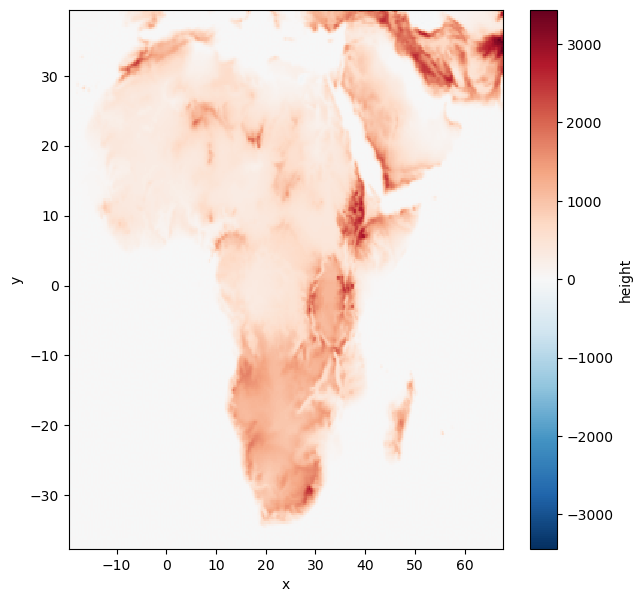

In [9]:
weather_cell["height"].plot()

## Create animation for (x,y,time) data
This works surprisingly easy with the hvplot and holomap.

- First, we create an interactive plot. We pick for that purpose the first 24 hours of the year and assess the `influx_diffuse` from the xarray variables. You can change by hand the timestamp.

- Second, we let the interactive plot convert in an animation with a cetain frames per second (fps) ratio. An fps ratio of 1 is equal to one picture in one second. 10 fps are 10 pictures in one second and therefore much faster. 

FYI, did you know that videos are nothing else then a lot of pictures? If the fps is too low we consider that as flickering. For most human eyes a smooth video is between 30 - 60 fps. https://www.healthline.com/health/human-eye-fps#how-vision-works

In [10]:
hv.extension("matplotlib")
ds = hv.Dataset(
    weather_cell["influx_diffuse"].isel(time=range(6, 10))
)  # range 3 can be replaced by time=2
images = ds.to(hv.Image, ["x", "y"]).options(
    fig_inches=(10, 5), colorbar=True, cmap="oranges", projection=ccrs.PlateCarree()
)
# hv.help(hv.Image) #  To see full documentation

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

In [11]:
# images

C:\Users\Marie\anaconda3\envs\pypsa-earth\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


:HoloMap   [time]
   :Overlay
      .Image.I     :Image   [x,y]   (influx_diffuse)
      .Borders.I   :Feature   [Longitude,Latitude]
      .Coastline.I :Feature   [Longitude,Latitude]
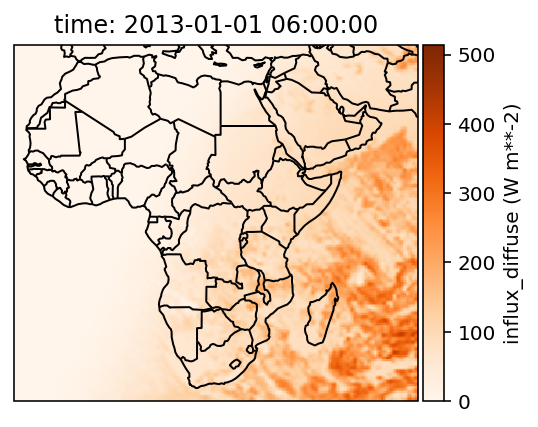
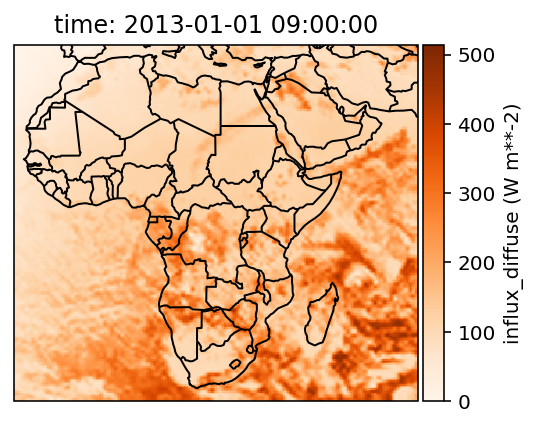
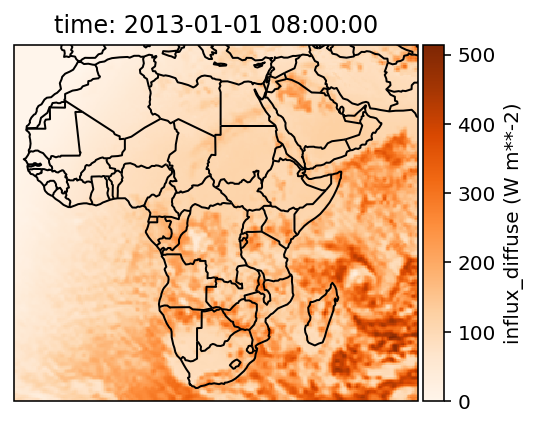
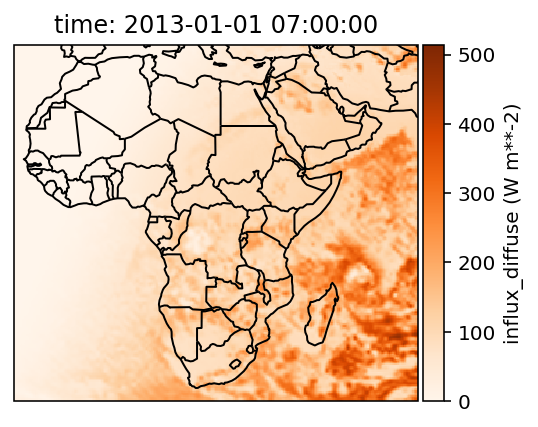
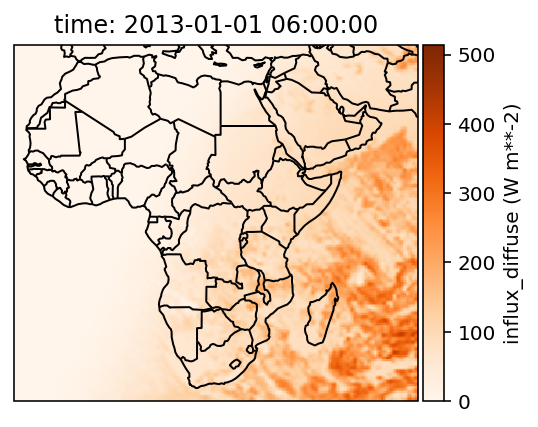

In [12]:
images * gv.feature.borders * gv.feature.coastline

In [13]:
# %%output holomap='mp4', fps=10
# images * gv.feature.borders * gv.feature.coastline

Now the interactive plots of each variable:

In [14]:
# TODO: Bug y,x axis labels are missing, y2 is cut.
# Reason for the bug is the geoviews (gv) and holoviews (hv) interaction.
# The hv plot alone had no borders/shape lines.
# We implemented gv to deal with it.

variables = [
    "wnd100m",
    "roughness",
    "influx_toa",
    "influx_direct",
    "influx_diffuse",
    "albedo",
    "temperature",
    "soil temperature",
    # "runoff",
]
color_maps = [
    "blues",
    "greys",
    "oranges",
    "oranges",
    "oranges",
    "viridis",
    "reds",
    "purples",
    # "greens",
]
i = 0

for variable in variables:
    i = i + 1
    ds = hv.Dataset(weather_cell[variable].isel(time=range(6, 30, 12)))
    images = ds.to(hv.Image, ["x", "y"]).options(
        fig_inches=(10, 5), colorbar=True, cmap=color_maps[i - 1]
    )
    # display(images * gv.feature.borders * gv.feature.coastline) # show plots in the notebook
    hv.save(images * gv.feature.borders * gv.feature.coastline, "documentation/" + variable + ".html");

### Full year animation (runs quite some time < 30min)

In [15]:
### COMMENTED IN FOR ANIMATION ###

# variables = ["wnd100m", "influx_direct", "temperature"]
# color_maps = ["blues", "oranges", "coolwarm"]
# i = 0

# for variable in variables:
#     i = i + 1
#     ds = hv.Dataset(weather_cell[variable].isel(time=range(24 * 100, 24 * 130, 1)))
#     images = ds.to(hv.Image, ["x", "y"]).options(
#         fig_inches=(10, 5), colorbar=True, cmap=color_maps[i - 1]
#     )
#     # hv.save(
#     #     images, f"{variable}_animation.mp4", fps=30
#     # )  # Changes the outputfile name automatically, fps=4 equals 1 day per second in our case

## Using Atlite we can use some plotting examples

Applied from https://atlite.readthedocs.io/en/latest/examples/plotting_with_atlite.html

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import geopandas as gpd
import pandas as pd
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

import cartopy.crs as ccrs
from cartopy.crs import PlateCarree as plate
import cartopy.io.shapereader as shpreader

import xarray as xr
import atlite

import logging
import warnings

warnings.simplefilter("ignore")
logging.captureWarnings(False)
logging.basicConfig(level=logging.INFO)

### Create shapes for Nigeria
- use the shapereader of Cartopy to retrieve high resoluted shapes
- make a GeoSeries with the shapes

In [19]:
shpfilename = shpreader.natural_earth(
    resolution="10m", category="cultural", name="admin_0_countries"
)
reader = shpreader.Reader(shpfilename)
KE = gpd.GeoSeries(
    {r.attributes["NAME_EN"]: r.geometry for r in reader.records()},
    crs={"init": "epsg:4326"},
).reindex(["Kenya"])

### Load cutout
- Will appear in the `pypsa-earth/cutouts/` after one run the pypsa-earth workflow

In [20]:
cutout_path = weather_cell_path
cutout = atlite.Cutout(path=cutout_path)
cutout.data

<xarray.Dataset> Size: 29GB
Dimensions:           (x: 291, y: 257, time: 8760)
Coordinates:
  * x                 (x) float64 2kB -19.5 -19.2 -18.9 -18.6 ... 66.9 67.2 67.5
  * y                 (y) float64 2kB -37.5 -37.2 -36.9 -36.6 ... 38.7 39.0 39.3
  * time              (time) datetime64[ns] 70kB 2013-01-01 ... 2013-12-31T23...
    lon               (x) float64 2kB dask.array<chunksize=(291,), meta=np.ndarray>
    lat               (y) float64 2kB dask.array<chunksize=(257,), meta=np.ndarray>
Data variables:
    height            (y, x) float32 299kB dask.array<chunksize=(257, 291), meta=np.ndarray>
    wnd100m           (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    roughness         (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    influx_toa        (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    influx_direct     (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    influx_diffuse    (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    albedo            (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    temperature       (time, y, x) float64 5GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    soil temperature  (time, y, x) float64 5GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
    runoff            (time, y, x) float32 3GB dask.array<chunksize=(100, 257, 291), meta=np.ndarray>
Attributes:
    module:             era5
    prepared_features:  ['runoff', 'influx', 'height', 'temperature', 'wind']
    chunksize_time:     100
    dx:                 0.3
    dy:                 0.3
    Conventions:        CF-1.6
    history:            2021-08-16 23:35:34 GMT by grib_to_netcdf-2.20.0: /op...

In [21]:
%matplotlib inline
cells = cutout.grid.buffer(0.01)
df = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
country_bound = gpd.GeoSeries(cells.unary_union)

projection = ccrs.Orthographic(5, 15)
fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(6, 6))
df.plot(ax=ax, transform=plate())
country_bound.plot(
    ax=ax, edgecolor="orange", linewidth=5, facecolor="None", transform=plate()
)
fig.tight_layout()

# plt.savefig("cutout-earthplot-nigeria.pdf", bbox_inches='tight')

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

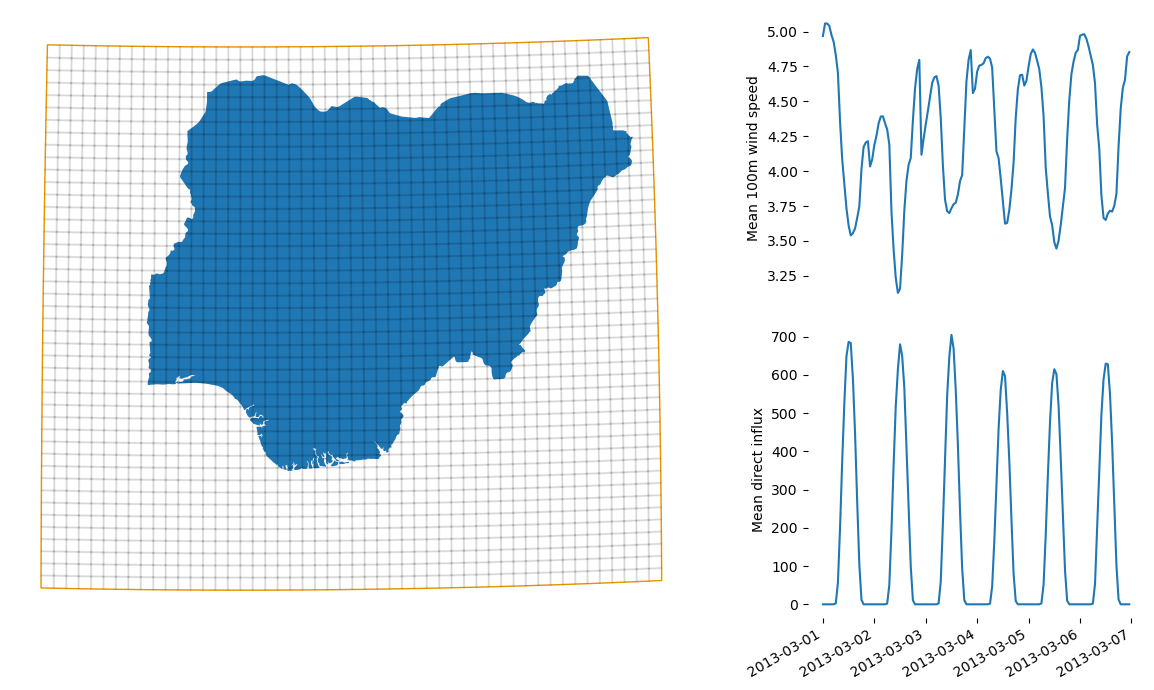

In [17]:
%matplotlib inline
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(2, 3, figure=fig)

ax = fig.add_subplot(gs[:, 0:2], projection=projection)
plot_grid_dict = dict(
    alpha=0.1,
    edgecolor="k",
    zorder=4,
    aspect="equal",
    facecolor="None",
    transform=plate(),
)
NG.plot(ax=ax, zorder=1, transform=plate())
cells.plot(ax=ax, **plot_grid_dict)
country_bound.plot(ax=ax, edgecolor="orange", facecolor="None", transform=plate())
ax.set_frame_on(False)

ax1 = fig.add_subplot(gs[0, 2])
cutout.data.wnd100m.mean(["x", "y"]).plot(ax=ax1)
ax1.set_frame_on(False)
ax1.set_ylabel("Mean 100m wind speed")
ax1.xaxis.set_visible(False)

ax2 = fig.add_subplot(gs[1, 2], sharex=ax1)
cutout.data.influx_direct.mean(["x", "y"]).plot(ax=ax2)
ax2.set_frame_on(False)
ax2.set_xlabel(None)
ax2.set_ylabel("Mean direct influx")
fig.tight_layout()

# plt.savefig("onshore-capacity-factor.pdf", bbox_inches='tight')

INFO:atlite.convert:Convert and aggregate 'wind'.


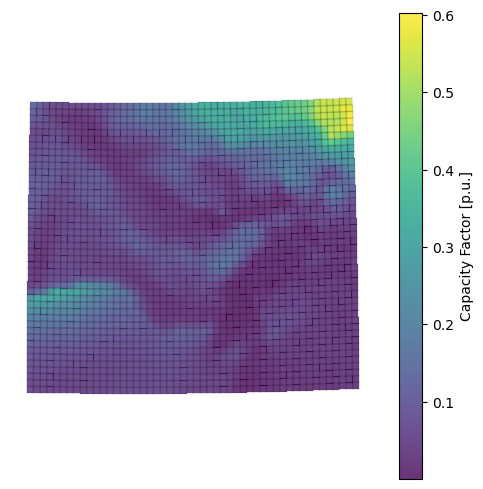

In [18]:
%matplotlib inline
cap_factors = cutout.wind(turbine="Vestas_V112_3MW", capacity_factor=True)

fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(5, 5))
cap_factors.name = "Capacity Factor"
cap_factors.plot(ax=ax, transform=plate(), alpha=0.8)
cells.plot(ax=ax, **plot_grid_dict)
ax.set_frame_on(False)
fig.tight_layout();

# plt.savefig("onshore-capacity-factor-nigeria.pdf", bbox_inches='tight')